# Summary of SQUID calibration procedure

Careful: in this script I talk about AI 0 and AI 1 squids; these labels are unfirtunately mismatched with the Quartz AI0 and AI1 ones. So AI 0 Squid $\longrightarrow$ AI1 Quartz and viceversa. \
## Settings on SQUIDs command software:
1) You have to set the bias parameters at the optimal values: put 'MON' line and 'channel1' on X-Y oscilloscope and observe $V-\Phi$ characteristic. You have to give a flux signal to the squid (using flux generator, like 30 Hz and 120 $\mu A$).  Set $I_b$ so that it maximises peak-to-peak. The tune $V_b$ and $\Phi_b$ so that the origin of axes coincides with maximal steepness point of the curve. Then switch to current generator and check the trace of channel 1 in time domain. You have to vary the $\Phi_b$ so that it's nice and traingular and with maximised peak to peak.\
To do this, you can limit BW of room-temp amp. (0.2 MHz is the smallest) to decrease noise. And turn off all resistors in the mode panel. \
If now you look at V-$\Phi$ transfer function, you can estimate the value of $V_{\Phi}$ at low frequencies/DC. Measure the $V_{\text period}$ (distance between 2 peaks on x axis), $\Delta$ X and $\Delta$ Y (horizontal and vertical distance between two arbitrary points on the steepest section of transfer function). and calculate $V_{\Phi}$ as: $V_{\Phi} = \frac{\Delta Y \, V_{\text period}}{\Delta X \, 2000}$, where 2000 is the gain of room temp amp. \
Next, you'll have to consider dynamic behaviour of $V_{\Phi}$ and measure it for all the frequencies of interest.
 2) You now want to give a flux input to SQUID via feedback coil (mutual inductance $M_f$ with squid loop). So you want to turn off all generators and turn on feedback resistor ($R_f$ = 2 $k \Omega$). You will need to generate a small voltage to inject in feedback coil (yellow 'flux' squid cable) and measure the channel1 output once again. You can do this in two ways

- Using a VNA $\longrightarrow$ broad sweep from 1 MHZ to 20 MHz to check for transfer between feedback coil and squid output.
- Using a signal generator to inject a tone of a specific frequency in the feedback coil and then Using a spectrum analyzer / FFT machine to measure the response of the SQUID at that specific frequency.

After a lot of hardships, managed to get equivalent results in this 2 ways.

## VNA version 
We want to give a very small flux input to SQUID (so we don't make the working point drift). So we use a lot of attenuation (like -29 dB): this way you can give few tens $\mu\Phi_0$ to the flux input.  \
Simple circuit analysis allows you to calculate the transfer from feedback coil to SQUID output. You get that $V_{\Phi}\, (\omega)$ follows the following formula:
$$ V_{\Phi}\, (\omega) = \frac{R_f}{2000 \, M_{\text f
}} \frac{V_{\text out} \, (\omega)}{V_{\text in} \, (\omega)}
$$

In [8]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

from os import listdir
from lmfit.models import LorentzianModel, LinearModel, ConstantModel

def dBm_to_Vrms(powerdbm, Z=50):
    pow = 1e-3*10**(powerdbm / 10)
    return np.sqrt(pow * Z)

def extrapolate_freqs(freqs, centers):
    '''freqs -> array-like set of frequencies sampled by VNA
    centers -> frequencies around which you want to extrapolate closest sample'''
    freqs_samples = np.zeros_like(centers)
    for i in range(centers.size):
        freqs_samples[i] = freqs[np.where(np.abs(freqs - centers[i]) == np.min(np.abs(freqs - centers[i])))]
    
    return freqs_samples

def extrapolate_index(freqs, center):
    '''freqs -> array-like set of frequencies sampled by VNA
    center -> frequency around which you want to extrapolate the closest sample'''

    # Get the index of the closest frequency
    closest_index = np.argmin(np.abs(freqs - center))
    
    return int(closest_index)

def extrapolate_indices(freqs, centers):
    '''freqs -> array-like set of frequencies sampled by VNA
    centers -> frequencies around which you want to extrapolate closest sample'''
    indices_samples = np.zeros_like(centers, dtype=int)  # Specify dtype as int for indices
    for i in range(centers.size):
        # Get the index of the closest frequency
        closest_index = np.argmin(np.abs(freqs - centers[i]))
        indices_samples[i] = closest_index  # Store the index
    return indices_samples

def lorentzian_fit_FFTM(filename, Plot=False, start = 0, stop = 1600):
    # Access file content        
    f = h5py.File(filename, 'r')
    fn = f['Frequency'][:]
    mag = f['Power Spectrum'][:]    # It's measured as a PSD in volts / rtHz
    f.close()

    # fit of resonance
    lor_mod = LorentzianModel(prefix = 'lor_') 
    #lin_mod = LinearModel(prefix='lin_')
    lin_mod = ConstantModel(prefix='lin_')
    fn_fit = fn[start:stop]
    linear_mag = mag[start:stop] # Should be correct?
    pars = lor_mod.guess(linear_mag, x=fn_fit)
    pars.update(lin_mod.make_params())
    mod = lin_mod + lor_mod
    out = mod.fit(linear_mag, pars, x=fn_fit)
    # Calculation of Q's

    Gamma = out.params["lor_sigma"].value * 2   # is it correct to multiply by 2?
    f_res = out.params["lor_center"].value
    Q = f_res/(Gamma)
    integral = out.params["lor_amplitude"].value
    sigma = out.params["lor_sigma"].value
    # plot of each fit
    if Plot:
        plt.plot(fn_fit, linear_mag, 'o', label = 'data')
        plt.title('Frequency: ' + str(f_res) + ' MHz')
        plt.plot(fn_fit, out.best_fit, '-', label='best fit')
        #plt.xlim(fn[710], fn[870])
        plt.legend()
        plt.show()
    return f_res, sigma, integral, Q

def lorentzian_fit_FFTM_squaring(filename, Plot=False, start = 0, stop = 1600):
    # Access file content        
    f = h5py.File(filename, 'r')
    fn = f['Frequency'][:]
    mag = f['Power Spectrum'][:]    # It's measured as a PSD in volts / rtHz
    f.close()

    # fit of resonance
    lor_mod = LorentzianModel(prefix = 'lor_') 
    #lin_mod = LinearModel(prefix='lin_')
    lin_mod = ConstantModel(prefix='lin_')
    fn_fit = fn[start:stop]
    linear_mag = mag[start:stop]**2 # Should be correct?
    pars = lor_mod.guess(linear_mag, x=fn_fit)
    pars.update(lin_mod.make_params())
    mod = lin_mod + lor_mod
    out = mod.fit(linear_mag, pars, x=fn_fit)
    # Calculation of Q's

    Gamma = out.params["lor_sigma"].value * 2   # is it correct to multiply by 2?
    f_res = out.params["lor_center"].value
    Q = f_res/(Gamma)
    integral = out.params["lor_amplitude"].value
    sigma = out.params["lor_sigma"].value
    # plot of each fit
    if Plot:
        plt.plot(fn_fit, linear_mag, 'o', label = 'data')
        plt.title('Frequency: ' + str(f_res) + ' MHz')
        plt.plot(fn_fit, out.best_fit, '-', label='best fit')
        #plt.xlim(fn[710], fn[870])
        plt.legend()
        plt.show()
    return f_res, sigma, integral, Q

from scipy.constants import k


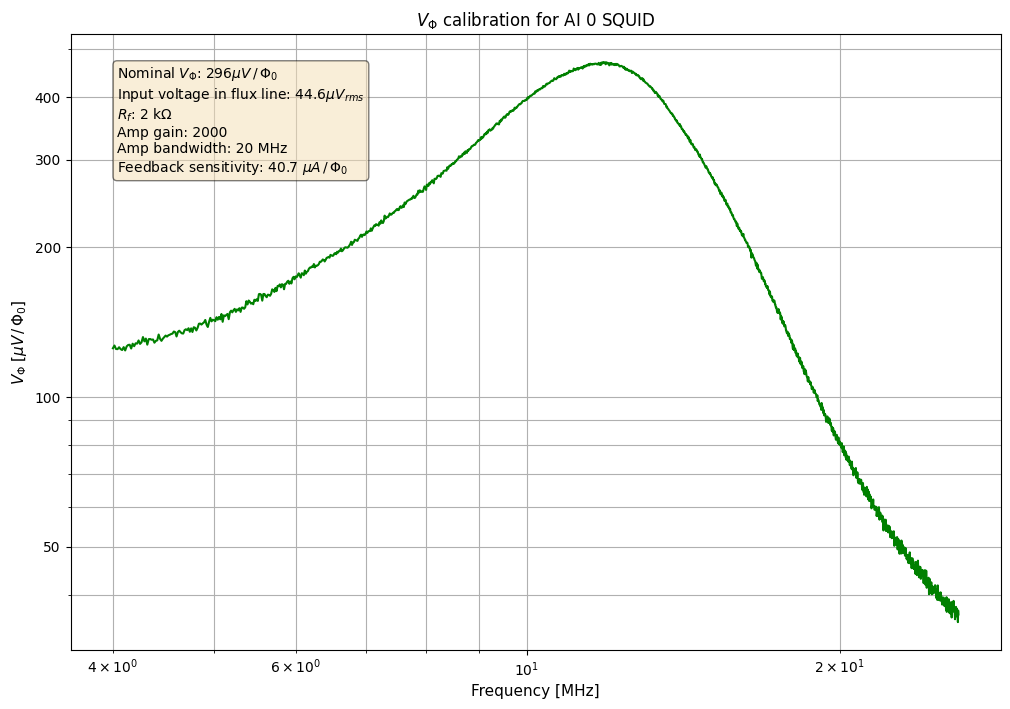

Maximum value of Vphi for ai 0 is 470.9315611274288 uV/Phi0


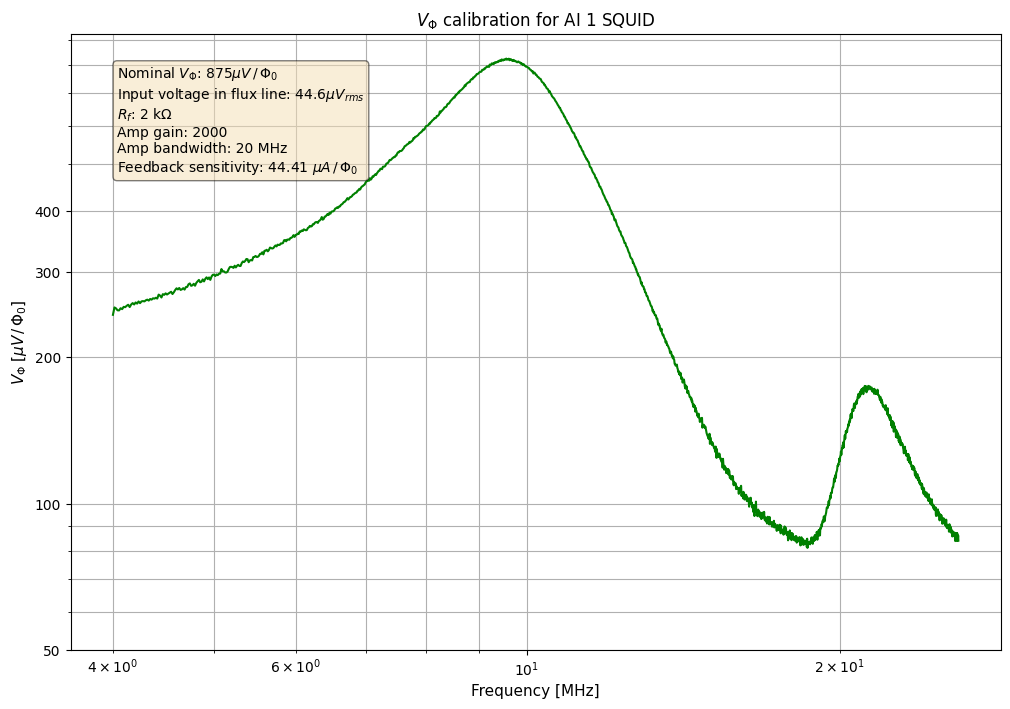

Maximum value of Vphi for ai 1 is 823.9359870080697 uV/Phi0


In [17]:
folder = '/home/leo_maria/Desktop/UWA/MAGE/October/Squid_cali_28_oct/'  # folder where your hdf5 files from vna measurement are
calibration_folder = '/home/leo_maria/Desktop/UWA/MAGE/calibration'     # folder where your calibration data is
atten29dB = True
Rf = 2000
gain = 2e3
pows = np.array([44.6e-6])
specific_y_ticks = [50, 100, 200, 300, 400]

for ai in [0,1]:
    filenames = ['AI' + str(ai) +'_-45dBm_-29dB-magn-phas-freq--15p000MHz--22000000.0HzSpan-10HzIFBW-S21.hdf5']
    if ai == 0:
        input_coup = 40.7e-6   
        nominalVphi=296
    if ai == 1:
        nominalVphi=875
        input_coup = 44.41e-6  

    header_rows = 10

    freqs_actualvna=np.zeros((2, h5py.File(folder + filenames[0], 'r')['Frequency'][:].size ))
    Vphi_actualvna=np.zeros_like(freqs_actualvna)
    fig = plt.figure(figsize=(12,8))
    for p, filename in enumerate(filenames):
        f = h5py.File(folder + filename, 'r')
        freqs = f['Frequency'][:]
        mags = f['Magnitude'][:, 0]
        ph = f['Phase'][:]
        f.close()
        if atten29dB:
            mags +=29
        V_ratio =  10 ** (mags/20)  # should be correct
        freqs_actualvna[ai, :] = freqs[:]
    
        Vphi_actualvna[ai, :] = Rf / gain * input_coup * V_ratio
        plt.plot(freqs/1e6, Vphi_actualvna[ai, :]*1e6, label='AI: ' + str(ai) + '; input Vrms: ' + str(pows[p]*1e3) + ' mVpp', color = 'green')
        #plt.scatter(single_tone_freqs/1e6, single_tone_Vphi[ai, 0, :, p]*1e6, label='Single tone with input Vpp: '+ str(pows[p]*1e3) + ' mVpp', color='green' )
        plt.xscale('log')
        plt.yscale('log')
        plt.gca().set_yticks(specific_y_ticks)
        plt.gca().set_yticklabels([f'{tick}' for tick in specific_y_ticks])  # Optional: Format tick labels
        plt.xlabel('Frequency [MHz]', fontsize=11)
        plt.ylabel(r'$V_{\Phi} \; [\mu V \, / \, \Phi_0]$', fontsize=11)
        plt.grid(True, which='both')
        plt.title(r'$V_{\Phi}$ calibration for AI ' + str(ai) + ' SQUID')
        # Adding a text box
        textstr = '\n'.join((
        r'Nominal $V_{\Phi}$: ' + str(nominalVphi) + r'$\mu V \, / \, \Phi_0$',
        r'Input voltage in flux line: ' + str(pows[p] *1e6) + r'$ \mu V_{rms}$',
        r'$R_f$: 2 k$\Omega$',
        r'Amp gain: 2000',
        r'Amp bandwidth: 20 MHz',
        r'Feedback sensitivity: ' + str(input_coup*1e6) + r' $\mu A \, / \, \Phi_0$'))

        #   Positioning the box
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        plt.gca().text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=10,
            verticalalignment='top', bbox=props)
        plt.show()
    print('Maximum value of Vphi for ai ' + str(ai) + ' is ' + str(np.max(Vphi_actualvna[ai, :])* 1e6) + ' uV/Phi0')

## Single tone with signal generator

You generate the tone and inject it in 'flux' input of squid. Then you measure channel1 with fftm. You do this procedure for all frequencies of interest: we actually pumped a few kHz away from every mode of the experiment since we were scared that, on resonance, the quartz might be excited somehow and fake the calibration. Actually I have later checked a few modes on resonance and it makes no appreciable difference.

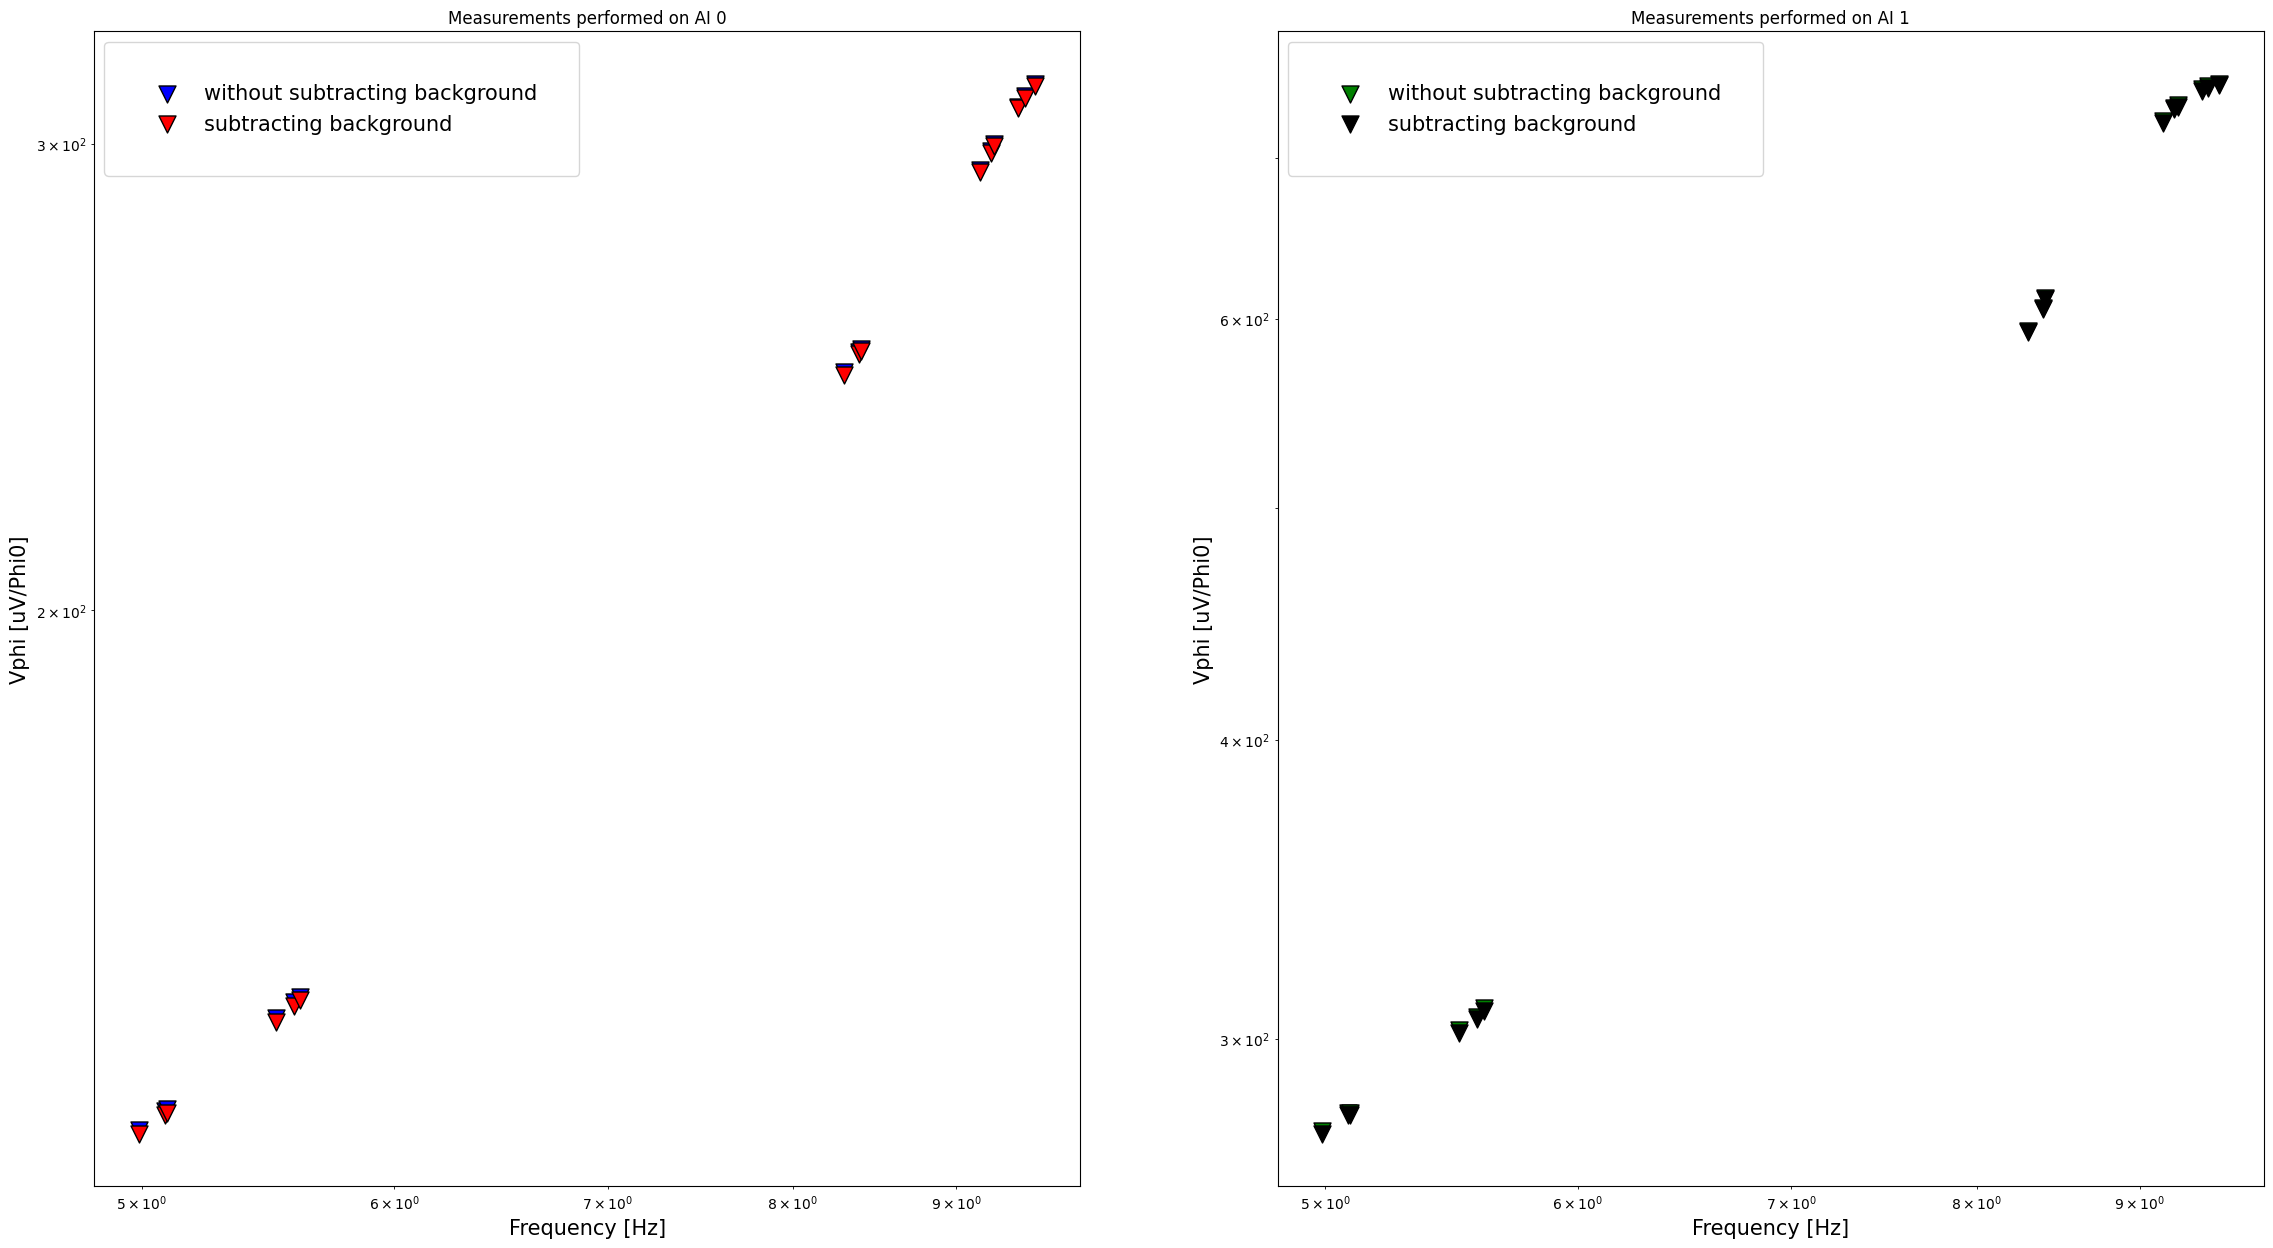

In [18]:
# 'Load' data

Nmodes=15
tones = np.zeros((2,Nmodes))
peaks = np.zeros_like(tones)
backgrounds = np.zeros_like(tones)
tones[0,:] = [4.99, 5.084, 5.091, 5.508, 5.580, 5.606, 8.300, 8.390, 8.404, 9.154, 9.228, 9.250, 9.413, 9.457, 9.53]
tones[1,:] = [4.99, 5.084, 5.091, 5.508, 5.580, 5.606, 8.300, 8.390, 8.404, 9.154, 9.228, 9.250, 9.413, 9.457, 9.53]
peaks[1,:] = [155, 157.7, 157.8, 170.8, 173.1, 174.5, 335.0, 342.5, 345.9, 409.9, 415.2, 416.2, 422.7, 423.9, 424.9]
peaks[0,:] =[78.5, 79.8, 79.9, 86.5, 87.7, 88.1, 151.6, 154.3, 154.7, 180.7, 183.7, 184.8, 191.0, 192.7, 194.8]
peaks=peaks*1e-6
backgrounds[0,:] = [275, 260, 260, 260, 260, 250, 290, 300, 290, 290, 290, 300, 300, 300, 300]
backgrounds[1,:] = [380, 315, 360, 380, 400, 390, 440, 490, 470, 560, 520, 520, 520, 510, 530]
backgrounds=backgrounds*1e-9
Vphi_singletone_last = np.zeros_like(tones)
Vphi_nobackground = np.zeros_like(tones)

ai = 0
Rf = 2000
Rf = 2e3
gain = 2e3
feed_coup = np.array([40.7e-6, 44.41e-6])
V0pp_atten = 2e-3 # -29 db atten
V0rms_atten = V0pp_atten / 2 /np.sqrt(2)
V0rms = 10**(-29 / 20) * V0rms_atten

for ai in [0,1]:

    # Conversion to Vphi
    Vphi_singletone_last[ai, :] = Rf / gain * feed_coup[ai] * peaks[ai, :] / V0rms
    Vphi_nobackground[ai, :] = Rf / gain * feed_coup[ai] * (peaks[ai, :] - backgrounds[ai, :]) / V0rms
 
fig, axs = plt.subplots(1, 2, figsize = (28, 15))
colors=['blue', 'green', 'red', 'black']
for AI, ax in enumerate(axs):
    ax.scatter(tones[ai,:], Vphi_singletone_last[AI, :] * 1e6, label='without subtracting background', color=colors[AI], edgecolor='black', s = 150, marker='v' )
    ax.scatter(tones[ai,:], Vphi_nobackground[AI, :] * 1e6, label='subtracting background', color=colors[AI+2], edgecolor='black', s = 150, marker='v' )

    ax.title.set_text('Measurements performed on AI ' + str(AI))
    ax.legend(fontsize=15, borderpad=2)
    ax.set_xlabel('Frequency [Hz]', fontsize=15)
    ax.set_ylabel('Vphi [uV/Phi0]', fontsize=15)
    ax.set_xscale('log')
    ax.set_yscale('log')

The difference between 'subtracting bg' or not is in the way you deal with the (white) broadband noise of fftm. In one case I subtracted it from the peak at pump frequency. In the other I have just let it there. No appreciable difference. Conceptually, it is probably more reasonable to let it there: noises sum up in quadrature: the white contribution is much lower than the peak, so it baiscally doesn't contribute at all.

## Comparison between the 2 ways

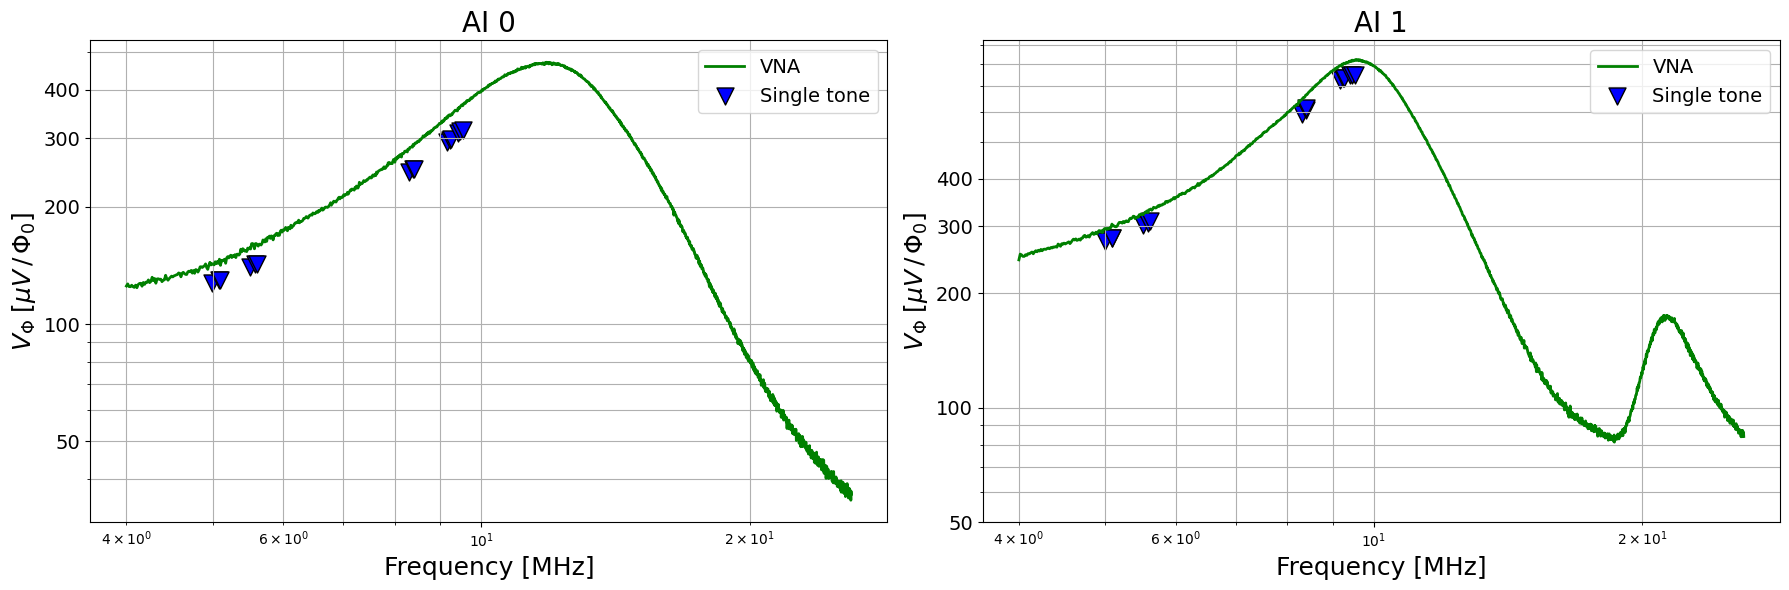

Maximum value of Vphi for ai 1 is 823.9359870080697 uV/Phi0
Vphi at 15 MHz: [0.00023484435672920588, 0.00011250302740811761]


In [19]:

ai = 0
atten29dB = True
Rf = 2000
gain = 2e3
pows = np.array([25e-6])
specific_y_ticks = [50, 100, 200, 300, 400]
fifteenMHz = [15.73437600E+6, 15.73195200E+6]
Vphi_fifteenMHz = [0, 0]
filenames = ['AI0_-45dBm_-29dB-magn-phas-freq--15p000MHz--22000000.0HzSpan-10HzIFBW-S21.hdf5']
header_rows = 10
freqs_actualvna = np.zeros((2, h5py.File(folder + filenames[0], 'r')['Frequency'][:].size))
Vphi_actualvna = np.zeros_like(freqs_actualvna)

fig = plt.figure(figsize=(18, 6))
for ai in [0, 1]:
    filenames = ['AI' + str(ai) +'_-45dBm_-29dB-magn-phas-freq--15p000MHz--22000000.0HzSpan-10HzIFBW-S21.hdf5']

    if ai == 0:
        input_coup = 40.7e-6   
        nominalVphi = 296
    if ai == 1:
        nominalVphi = 875
        input_coup = 44.41e-6  

    f = h5py.File(folder + filenames[0], 'r')
    freqs = f['Frequency'][:]
    mags = f['Magnitude'][:, 0]
    ph = f['Phase'][:]
    f.close()

    if atten29dB:
        mags += 29

    V_ratio = 10 ** (mags / 20)  # Correct conversion
    freqs_actualvna[ai, :] = freqs[:]
    Vphi_actualvna[ai, :] = Rf / gain * input_coup * V_ratio
    index_15MHz = extrapolate_index(freqs, fifteenMHz[ai])
    Vphi_fifteenMHz[ai] = Vphi_actualvna[ai, index_15MHz] 

    # Plotting each AI data on the corresponding subplot
    plt.subplot(1, 2, ai + 1)
    plt.plot(freqs / 1e6, Vphi_actualvna[ai, :] * 1e6, label='VNA', color='green', linewidth=2)
    plt.scatter(tones[ai, :], Vphi_singletone_last[ai, :] * 1e6, label='Single tone', color='blue', edgecolor='black', s=150, marker='v')
    
    plt.xscale('log')
    plt.yscale('log')
    plt.gca().set_yticks(specific_y_ticks)
    plt.gca().set_yticklabels([f'{tick}' for tick in specific_y_ticks], fontsize=14)  # Bigger Y tick labels
    
    # Increasing font size for axes labels, title, etc.
    plt.xlabel('Frequency [MHz]', fontsize=18)
    plt.ylabel(r'$V_{\Phi} \; [\mu V \, / \, \Phi_0]$', fontsize=18)
    plt.title(f'AI {ai}', fontsize=20)
    
    # Increase legend font size
    plt.legend(fontsize=14)
    
    # Grid and further customization
    plt.grid(True, which='both')

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the plot
plt.show()

print('Maximum value of Vphi for ai ' + str(ai) + ' is ' + str(np.max(Vphi_actualvna[ai, :]) * 1e6) + ' uV/Phi0')
print('Vphi at 15 MHz: ' + str(Vphi_fifteenMHz))


 Decent agreement:  for the mode temperature calculation I have used the single tone ones

## Mode effective temperatures 
By removing all sorts of generators / flux inputs, one can use a fftm to just measure the thermal peaks that appear at mode frequency. Since the crystal is sitting at finite temperature, the modes are never completely 'off' and they are always excited via thermal effects. If you use a fftm and average for long enough, you can fit the lorentzian and infer about the effective temperature of the resonator modes. \
You have to calculate the transfer from the thermal Johnson noise of the resonator (on resonance you just consider its motional resistance) to the psd you measure on the fftm. You want to measure it as a density (linear units, Volts per $\sqrt{Hz}$). The formula you need to calculate this is Johnson-Nyquist theorem: a resistor $R_{\lambda}$ at temperature T is equivalent to noisless resistor $R_{\lambda}$ in parallel with current generator with rms value $$\delta i = \frac{4 \, K \, T \Delta f}{R_{\lambda}}.$$
Then you do circuit analysis and see that (considering the impedance of input coil as well , which makes a bit of a difference):
$$T_{\text eff} = \frac{R_{\text BAW}^2 + \omega^2 \, L_ {in}^2}{4 \, k R_{\lambda} \, (2000 \, V_{\Phi} \, M_{in})^2} \left( \frac{\delta V_{\text out}}  {\sqrt{\text Hz}}\right) ^2 \, ,$$
where $k$ is Boltzmann constant, $M_{\text in}$ is the value of mutual inductance between iunput coil and squid, $L_{\text in }$ is the inductance of input coil, $\delta V_{\text out }$ is the rms value of the maximum of the thermal peak as measured by fftm.


In [20]:
# Define and retrieve anything you need. ONLY RUN ONCE otherwise you'll zero everything
Nmodes = 15
Rbaw=np.zeros((2, Nmodes)) # remember that ai quartz and squids are not matching
f_res = np.zeros_like(Rbaw)
integrals = np.zeros_like(Rbaw)
maxima = np.zeros_like(Rbaw)
sigmas = np.zeros_like(Rbaw)
eugene_f_res = np.zeros_like(Rbaw)
eugene_integrals = np.zeros_like(Rbaw)
eugene_maxima = np.zeros_like(Rbaw)
eugene_sigmas = np.zeros_like(Rbaw)
const_f_res = np.zeros_like(Rbaw)
const_integrals = np.zeros_like(Rbaw)
const_maxima = np.zeros_like(Rbaw)
const_sigmas = np.zeros_like(Rbaw)
const_c = np.zeros_like(Rbaw)
R_import = np.zeros_like(Rbaw)
Q_import = np.zeros_like(Rbaw)
Q = np.zeros_like(Rbaw)
eugene_Q = np.zeros_like(Rbaw)
const_Q = np.zeros_like(Rbaw)
temperatures = np.zeros_like(Rbaw)
eugene_temperatures = np.zeros_like(Rbaw)
const_temperatures = np.zeros_like(Rbaw)
VNA_temperatures = np.zeros_like(Rbaw)
V_phi_singletone = np.zeros_like(Rbaw)
V_phi_samples = np.zeros_like(Rbaw)

def lorentzian_fit_FFTM_whole_height(filename, Plot=False, start = 0, stop = 1600):
    # Access file content        
    f = h5py.File(filename, 'r')
    fn = f['Frequency'][:]
    mag = f['Power Spectrum'][:]    # It's measured as a PSD in volts / rtHz
    f.close()

    # fit of resonance
    lor_mod = LorentzianModel(prefix = 'lor_') 
    #lin_mod = LinearModel(prefix='lin_')
    lin_mod = ConstantModel(prefix='lin_')
    fn_fit = fn[start:stop]
    linear_mag = mag[start:stop] # Should be correct?
    pars = lor_mod.guess(linear_mag, x=fn_fit)
    pars.update(lin_mod.make_params())
    mod = lin_mod + lor_mod
    out = mod.fit(linear_mag, pars, x=fn_fit)

    # Calculation of Q's
    Gamma = out.params["lor_sigma"].value * 2   # is it correct to multiply by 2?
    f_res = out.params["lor_center"].value
    Q = f_res/(Gamma)
    integral = out.params["lor_amplitude"].value
    sigma = out.params["lor_sigma"].value
    const = out.params["lin_c"].value

    # plot of each fit
    if Plot:
        plt.plot(fn_fit, linear_mag, 'o', label = 'data')
        plt.title('Frequency: ' + str(f_res) + ' MHz')
        plt.plot(fn_fit, out.best_fit, '-', label='best fit')
        #plt.xlim(fn[710], fn[870])
        plt.legend()
        plt.show()
    return f_res, sigma, integral, Q, const
Lin = 400e-9

Rbaw[0, :] = np.array([3.518, 69.566, 48.289, 3.281, 52.537, 12.560, 5.567, 43.994, 7.476, 17.934, 9.060, 41.247, 10.885, 10.112, 8.624])
Rbaw[1, :] = np.array([8.51, 255.28, 89.55, 9.30, 57.84, 12.48, 12.06, 43.01, 10.21, 12.24, 10.06, 12.71, 12.72, 13.48, 8.13])

# import Q and R data from calibration file
AI = 0
filename = calibration_folder +'/resistances_and_Q_AI1_3.72K.txt'  # Remember that AI numbers are switched between squids and quartz
data = np.loadtxt(filename, delimiter='\t', skiprows=1, usecols=(0, 1))
data = data[:-1]
R_import[AI, :] = data[:, 0]  # First column
Q_import[AI, :] = data[:, 1]  # Second column

AI = 1
filename = calibration_folder + '/resistances_and_Q_AI0_3.49K.txt'  # Replace with your actual file name
data = np.loadtxt(filename, delimiter='\t', skiprows=1, usecols=(0, 1))
data = data[:-1]
R_import[AI, :] = data[:, 0]  # First column
Q_import[AI, :] = data[:, 1]  # Second column

['AI0_ thermal_ch0_ 4993050.0MHz-magn-freq-.hdf5', 'AI0_ thermal_ch1_ 5080854.0MHz-magn-freq-.hdf5', 'AI0_ thermal_ch2_ 5088263.0MHz-magn-freq-.hdf5', 'AI0_ thermal_ch3_ 5505426.0MHz-magn-freq-.hdf5', 'AI0_ thermal_ch4_ 5576856.0MHz-magn-freq-.hdf5', 'AI0_ thermal_ch5_ 8392272.0MHz-magn-freq-.hdf5', 'AI0_ thermal_ch6_ 9151802.0MHz-magn-freq-.hdf5', 'AI0_ thermal_ch7_ 9409902.0MHz-magn-freq-.hdf5', 'AI0_ thermal_ch8_ 9452381.0MHz-magn-freq-.hdf5', 'AI0_ thermal_ch9_ 5603804.0MHz-magn-freq-.hdf5', 'AI0_ thermal_ch10_ 8297640.0MHz-magn-freq-.hdf5', 'AI0_ thermal_ch11_ 8400189.0MHz-magn-freq-.hdf5', 'AI0_ thermal_ch12_ 9224931.0MHz-magn-freq-.hdf5', 'AI0_ thermal_ch13_ 9246863.0MHz-magn-freq-.hdf5', 'AI0_ thermal_ch14_ 9526448.0MHz-magn-freq-.hdf5']
['AI1_ thermal_ch0_ 4993021.0MHz-magn-freq-.hdf5', 'AI1_ thermal_ch1_ 5080764.0MHz-magn-freq-.hdf5', 'AI1_ thermal_ch2_ 5088518.0MHz-magn-freq-.hdf5', 'AI1_ thermal_ch3_ 5505659.0MHz-magn-freq-.hdf5', 'AI1_ thermal_ch4_ 5577295.0MHz-magn-freq-.

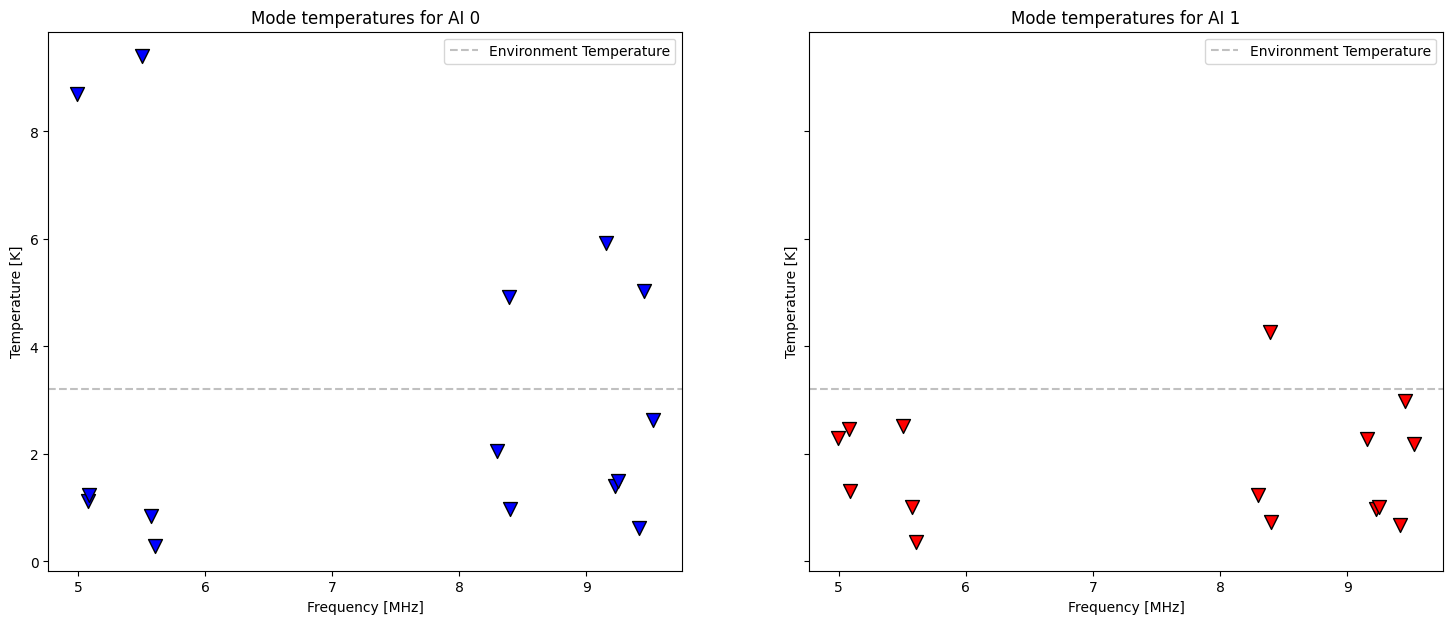

In [21]:
imped_mismatch = False
import re
for ai in range(2):
    # Access files
    if ai == 0:
        folder = calibration_folder + '/FFTM_thermal_modes/AI0/'
        Min = 1 / 0.49 / 1e-6
    if ai == 1:
        folder = calibration_folder + '/FFTM_thermal_modes/AI1/'
        Min = 1 / 0.517 / 1e-6
    # Function to extract the number after 'ch' in each string
    def extract_number(s):
        match = re.search(r'ch(\d+)', s)  # This finds the number after 'ch'
        return int(match.group(1)) if match else 0  # Return the number as integer, or 0 if not found

    # Sort the list using the extracted number as the key
    files = sorted(listdir(folder), key=extract_number)
    
    print(files)
    # Fit thermal peaks
    for index, file in enumerate(files):
        f_res[ai, index], sigmas[ai, index], integrals[ai, index], Q[ai,index] = lorentzian_fit_FFTM(folder + file, Plot=False)
        eugene_f_res[ai, index], eugene_sigmas[ai, index], eugene_integrals[ai, index], eugene_Q[ai,index] = lorentzian_fit_FFTM_squaring(folder + file, Plot=False)
        const_f_res[ai, index], const_sigmas[ai, index], const_integrals[ai, index], const_Q[ai,index], const_c[ai, :] = lorentzian_fit_FFTM_whole_height(folder + file, Plot=False)
        
    # Get maximum value of fitted lorentzian
    maxima[ai, :] = integrals[ai, :] / np.pi / sigmas[ai, :]
    const_maxima[ai, :] = integrals[ai, :] / np.pi / sigmas[ai, :] + const_c[ai, :]

    # Retrieve Vphi from singletone
    column1 = []
    column2 = []
    with open(calibration_folder+ '/Vphi_last_singletone.txt', 'r') as file:
        # Iterate through each line of the file
        next(file)
        for line in file:
            # Split the line by tab to get both values
            values = line.split('\t')
            # Convert the values to float and append to the respective arrays
            column1.append(float(values[0]))
            column2.append(float(values[1].strip()))  # Use strip() to remove any newline character
    V_phi_singletone[0, :] = np.array(column1)
    V_phi_singletone[1, :] = np.array(column2)

    # Retrieve Vphi from VNA
    sample_indices = extrapolate_indices(freqs_actualvna[ai, :], f_res[ai, :])
    V_phi_samples[ai, :] = Vphi_actualvna[ai, sample_indices]


    # Calculate effective temps Will way
    temperatures[ai, :] = (Rbaw[ai, :]**2 + (2*np.pi *f_res[ai,:] * Lin)**2 ) / (4 * k * Rbaw[ai, :] * (2000 * V_phi_singletone[ai, :] * Min)**2 ) * maxima[ai, :]**2
    const_temperatures[ai, :] = (Rbaw[ai, :]**2 + (2*np.pi *f_res[ai,:] * Lin)**2 ) / (4 * k * Rbaw[ai, :] * (2000 * V_phi_singletone[ai, :] * Min)**2 ) * const_maxima[ai, :]**2
    VNA_temperatures[ai, :] = (Rbaw[ai, :]**2 + (2*np.pi *f_res[ai,:] * Lin)**2 ) / (4 * k * Rbaw[ai, :] * (2000 * V_phi_samples[ai, :] * Min)**2 ) * const_maxima[ai, :]**2

    # Calculate effective temps Eugene's way
    def temp_eff_from_integral_squaring(Rbaw, integral, sigma, Vphi):
        if imped_mismatch:
            integral = integral * 1.087
        return (Rbaw  / 2000 / Min / Vphi)**2 * integral / 4 / k / np.pi / sigma

    eugene_temperatures[ai, :] = temp_eff_from_integral_squaring(Rbaw[ai, :], eugene_integrals[ai, :], eugene_sigmas[ai, :], V_phi_singletone[ai, :])

#print (' effective temperature using Single tone cali, Will way: ' + str (np.round(temperatures, 2)) + ' K')
print (' effective temperature using Single tone cali, Wil way + constant: ' + str (np.round(const_temperatures, 2)) + ' K')
print (' effective temperature using VNA cali, Wil way + constant: ' + str (np.round(VNA_temperatures, 2)) + ' K')

# Plot of results

fig, axs = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
colors=['blue', 'red']

for ai in [0, 1]:
    #axs[ai].scatter(f_res[ai, :] / 1e6, VNA_temperatures[ai, :], color=colors[0], marker='v', s=70, edgecolors='black', label='Will way + constant, VNA cali')
    axs[ai].scatter(const_f_res[ai, :] / 1e6, const_temperatures[ai, :], color=colors[ai], marker='v', s=100, edgecolors='black') #, label='Will way + constant, single tone cali'
    axs[ai].axhline(y=3.2, color='silver', linestyle='--', label="Environment Temperature")
    #axs[ai].scatter(eugene_f_res[ai, :] / 1e6, eugene_temperatures[ai, :], color=colors[1], marker='v', s=70, edgecolors='black', label='Eugene way')
    axs[ai].legend()
    axs[ai].set_xlabel('Frequency [MHz]')
    axs[ai].set_ylabel('Temperature [K]')
    axs[ai].set_title('Mode temperatures for AI ' + str(ai))
    #axs[ai].set_ylim(-0.1,5)



Doesn't seem to make too much sense, but when  you try and plot these temps as function of mode motional reistance (instead of mode frequency), you see an interesting behaviour

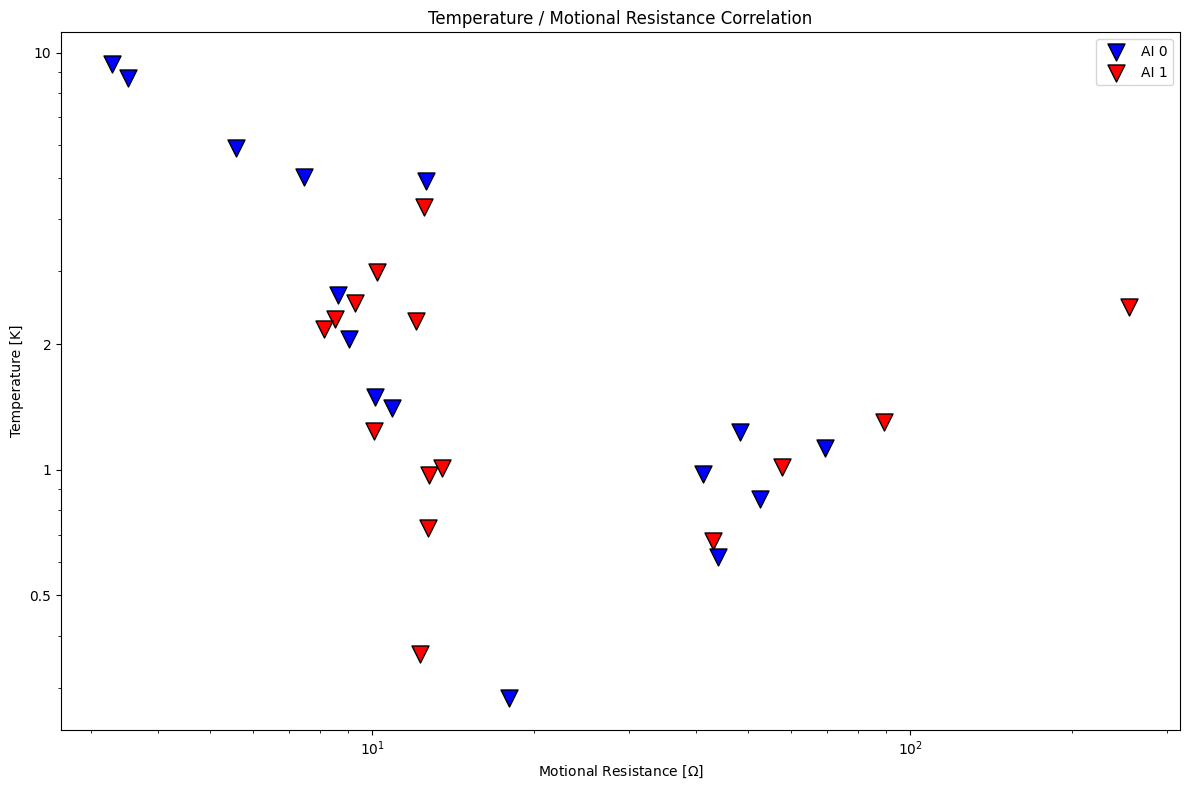

In [14]:

# Assuming Rbaw, const_temperatures, and colors are already defined

plt.figure(figsize=(12, 8))

# Create a single axis (no subplots, just one plot)
ax = plt.gca()  # Get the current axes

# Define custom y-ticks
custom_yticks = [0.5, 1, 2, 10]  # Example y-tick positions in log scale

# Loop to plot both datasets on the same plot
for ai in [0, 1]:
    ax.scatter(Rbaw[ai, :], const_temperatures[ai, :], label='AI ' + str(ai), marker='v', s=150, color=colors[ai], edgecolor='black')

# Set labels, title, and axis scales
ax.set_xlabel(r'Motional Resistance $[\Omega]$')
ax.set_ylabel('Temperature [K]')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Temperature / Motional Resistance Correlation')

# Set custom y-ticks
ax.set_yticks(custom_yticks)
ax.set_yticklabels([f'{tick}' for tick in custom_yticks])  # Optional: Format tick labels

# Show legend
ax.legend()

# Show the plot
plt.tight_layout()  # Adjust layout for better spacing
plt.show()


Both AIs seem to agree on this behaviour. Seems like there's a minimum of temperature around 15 - 20 $\Omega$. Is this some impedance mathcing condition between quartz and SQUID input impedance?